In [1]:
import matplotlib.font_manager as fm
from matplotlib import rcParams

font_path = '/home/shariat/Documents/fonts/Helvetica.ttf'
fm.fontManager.addfont(font_path)           # add it globally
rcParams['font.family'] = 'Helvetica'  # set default

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

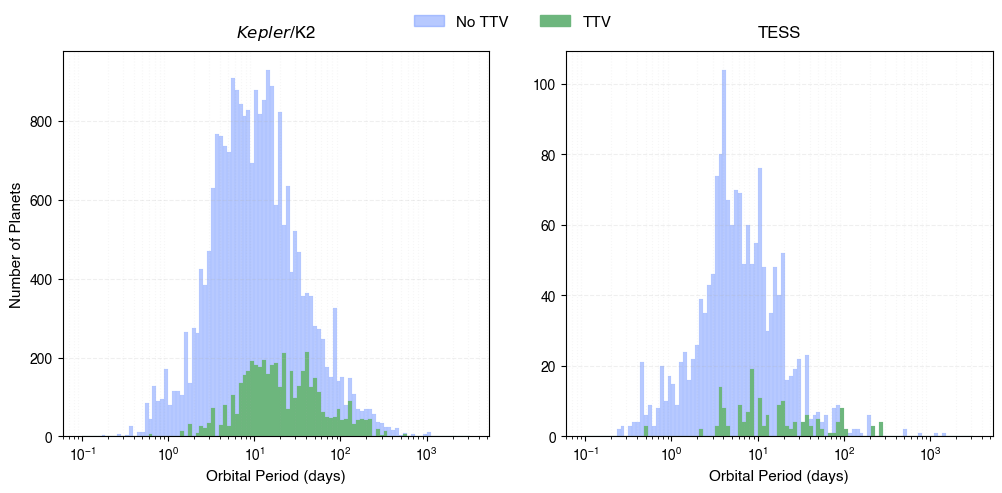

In [26]:
# 1. Load and clean data
data = pd.read_csv('/home/shariat/Astronomy/TTV/Data/PS_2025.10.03_12.37.12.csv', comment='#')
df = data.dropna(subset=['pl_orbper', 'ttv_flag']).copy()
df = df[df['pl_orbper'] > 0]

# Filter by mission
kepler_k2 = df[df['disc_facility'].isin(['Kepler', 'K2'])].copy()
tess = df[df['disc_facility'] == 'Transiting Exoplanet Survey Satellite (TESS)'].copy()

# 2. Define log-spaced bins
bins = np.logspace(np.log10(0.1), np.log10(3162), 100)

# 3. Create figure with TWO side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False)  # No sharey → independent y-limits
fig.subplots_adjust(wspace=0.18)  # horizontal spacing between plots

# ── Left panel: Kepler + K2 ────────────────────────────────────────
ax1 = axes[0]

ax1.hist(kepler_k2[kepler_k2['ttv_flag'] == 0]['pl_orbper'],
         bins=bins, alpha=0.5, color='#7095ff', edgecolor='#7095ff', linewidth=0.1,
         label='No TTV')
ax1.hist(kepler_k2[kepler_k2['ttv_flag'] == 1]['pl_orbper'],
         bins=bins, alpha=1.0, color='#6db67d', edgecolor='#6db67d', linewidth=0.1,
         label='TTV')

ax1.set_xscale('log')
ax1.set_xlabel('Orbital Period (days)', fontsize=11)
ax1.set_ylabel('Number of Planets', fontsize=11)
ax1.set_title('$Kepler$/K2', fontsize=12, pad=10)
ax1.grid(True, which='major', axis='y', ls='--', alpha=0.2)
ax1.grid(True, which='minor', axis='x', ls=':', alpha=0.1)

# ── Right panel: TESS ──────────────────────────────────────────────
ax2 = axes[1]

ax2.hist(tess[tess['ttv_flag'] == 0]['pl_orbper'],
         bins=bins, alpha=0.5, color='#7095ff', edgecolor='#7095ff', linewidth=0.1,
         label='No TTV')
ax2.hist(tess[tess['ttv_flag'] == 1]['pl_orbper'],
         bins=bins, alpha=1.0, color='#6db67d', edgecolor='#6db67d', linewidth=0.1,
         label='TTV')

ax2.set_xscale('log')
ax2.set_xlabel('Orbital Period (days)', fontsize=11)
ax2.set_title('TESS', fontsize=12, pad=10)
ax2.grid(True, which='major', axis='y', ls='--', alpha=0.2)
ax2.grid(True, which='minor', axis='x', ls=':', alpha=0.1)

# 4. Shared legend at the top center of the figure
handles = [
    plt.Rectangle((0,0), 1, 1, color='#7095ff', alpha=0.5, ec='#7095ff'),
    plt.Rectangle((0,0), 1, 1, color='#6db67d', alpha=1.0, ec='#6db67d')
]
labels = ['No TTV', 'TTV']

fig.legend(handles, labels,
           loc='upper center',
           bbox_to_anchor=(0.5, 0.98),
           ncol=2,
           frameon=False,
           fontsize=11)



# Optional: set explicit (but nice round) y-limits after seeing the data
# Uncomment and adjust numbers after first run if needed
# ax1.set_ylim(0, 1500)   # example for Kepler/K2
# ax2.set_ylim(0, 200)    # example for TESS

# 6. Save and show
plt.savefig('figures/data_imbalance_viz.pdf')
plt.show()